# Day 15: Decision Tree Classification

**Dataset:** `tennis.csv`

In this notebook, we will:
1. Understand how the Decision Tree algorithm works
2. Learn about Entropy, Information Gain, and the ID3 algorithm
3. Load and explore the Tennis dataset
4. Encode categorical features for scikit-learn
5. Build a Decision Tree classifier
6. Visualize the tree structure
7. Make predictions and evaluate the model

## 1. Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

## 2. What is a Decision Tree?

A Decision Tree is a flowchart-like structure where:
- Each **internal node** represents a test on a feature (e.g., "Is Outlook Sunny?")
- Each **branch** represents the outcome of that test
- Each **leaf node** represents a class label (the final decision)

### How it works:
1. Start with the entire dataset at the root
2. Pick the **best feature** to split on (the one that gives the most information)
3. Create branches for each possible value of that feature
4. Repeat for each branch until all data in a branch belongs to one class (or we hit a stopping condition)

### Key Question: How do we pick the "best" feature?
We use **Entropy** and **Information Gain**.

## 3. Entropy and Information Gain

### Entropy
Entropy measures the **impurity** or **disorder** in a set of data.

$$H(S) = -\sum_{i=1}^{c} p_i \log_2(p_i)$$

Where $p_i$ is the proportion of class $i$ in the set $S$.

- **Entropy = 0**: All samples belong to the same class (pure)
- **Entropy = 1**: Samples are equally split between classes (maximum impurity for binary)

### Information Gain
Information Gain tells us how much **entropy decreases** after splitting on a feature.

$$IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)$$

We pick the feature with the **highest Information Gain** at each step.

## 4. Load and Explore the Tennis Dataset

In [2]:
df = pd.read_csv('tennis.csv')
print("Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Shape: (14, 5)

First few rows:


,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [3]:
print("Dataset Info:")
print(df.info())
print("\nValue counts for target (PlayTennis):")
print(df['PlayTennis'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      14 non-null     object
 1   Temperature  14 non-null     object
 2   Humidity     14 non-null     object
 3   Wind         14 non-null     object
 4   PlayTennis   14 non-null     object
dtypes: object(5)
memory usage: 688.0+ bytes
None

Value counts for target (PlayTennis):
PlayTennis
Yes    9
No     5
Name: count, dtype: int64


In [4]:
print("Unique values in each feature:")
for col in df.columns:
    print(f"  {col}: {df[col].unique()}")

Unique values in each feature:
  Outlook: ['Sunny' 'Overcast' 'Rain']
  Temperature: ['Hot' 'Mild' 'Cool']
  Humidity: ['High' 'Normal']
  Wind: ['Weak' 'Strong']
  PlayTennis: ['No' 'Yes']


## 5. Manual Entropy Calculation

Let's manually compute entropy for the target variable to understand the concept.

In [5]:
def entropy(target):
    """Calculate entropy of a target variable."""
    values, counts = np.unique(target, return_counts=True)
    probabilities = counts / len(target)
    return -np.sum(probabilities * np.log2(probabilities))

# Entropy of the whole dataset
total_entropy = entropy(df['PlayTennis'])
print(f"Total Entropy of PlayTennis: {total_entropy:.4f}")
print(f"  Yes: {sum(df['PlayTennis'] == 'Yes')}/14, No: {sum(df['PlayTennis'] == 'No')}/14")


Total Entropy of PlayTennis: 0.9403
  Yes: 9/14, No: 5/14


In [6]:
def information_gain(data, feature, target):
    """Calculate Information Gain when splitting on a feature."""
    total_ent = entropy(data[target])
    
    # Weighted entropy after split
    values = data[feature].unique()
    weighted_ent = 0
    for val in values:
        subset = data[data[feature] == val]
        weight = len(subset) / len(data)
        weighted_ent += weight * entropy(subset[target])
    
    return total_ent - weighted_ent

# Calculate Information Gain for each feature
print("Information Gain for each feature:")
print("=" * 40)
for feature in ['Outlook', 'Temperature', 'Humidity', 'Wind']:
    ig = information_gain(df, feature, 'PlayTennis')
    print(f"  IG({feature}) = {ig:.4f}")

print("\n=> Outlook has the highest IG, so it becomes the root node!")

Information Gain for each feature:
  IG(Outlook) = 0.2467
  IG(Temperature) = 0.0292
  IG(Humidity) = 0.1518
  IG(Wind) = 0.0481

=> Outlook has the highest IG, so it becomes the root node!


## 6. Encode Categorical Features

Scikit-learn requires numerical input. We'll use `LabelEncoder` to convert each categorical column to numbers.

In [7]:
df_encoded = df.copy()
label_encoders = {}

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nEncoded Dataset:")
df_encoded.head()

Outlook: {'Overcast': np.int64(0), 'Rain': np.int64(1), 'Sunny': np.int64(2)}
Temperature: {'Cool': np.int64(0), 'Hot': np.int64(1), 'Mild': np.int64(2)}
Humidity: {'High': np.int64(0), 'Normal': np.int64(1)}
Wind: {'Strong': np.int64(0), 'Weak': np.int64(1)}
PlayTennis: {'No': np.int64(0), 'Yes': np.int64(1)}

Encoded Dataset:


,Outlook,Temperature,Humidity,Wind,PlayTennis
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1


## 7. Split Features and Target

In [16]:
X = df_encoded.drop('PlayTennis', axis=1)
y = df_encoded['PlayTennis']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (14, 4)
Target shape: (14,)

Feature columns: ['Outlook', 'Temperature', 'Humidity', 'Wind']


## 8. Build the Decision Tree Classifier

We use `criterion='entropy'` to match our manual calculation (ID3 algorithm).

In [17]:
# Build Decision Tree with entropy criterion (ID3 algorithm)
dt_classifier = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_classifier.fit(X, y)

print("Decision Tree trained successfully!")
print(f"Tree depth: {dt_classifier.get_depth()}")
print(f"Number of leaves: {dt_classifier.get_n_leaves()}")

Decision Tree trained successfully!
Tree depth: 4
Number of leaves: 7


## 9. Visualize the Decision Tree

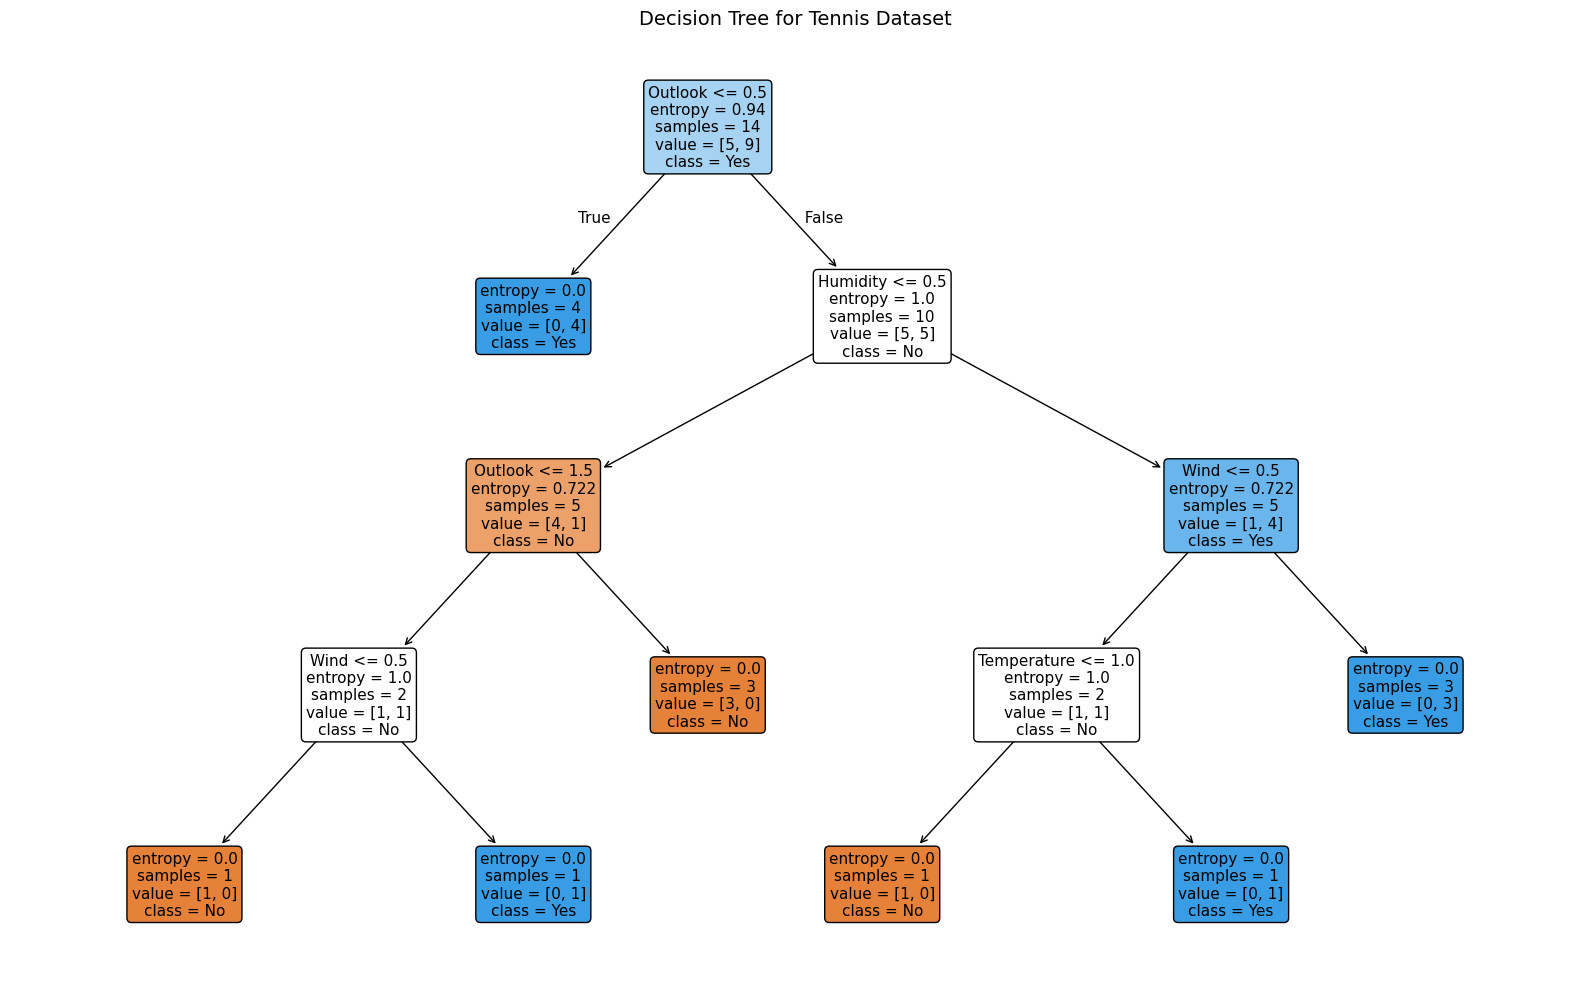

In [20]:
plt.figure(figsize=(16, 10))
plot_tree(dt_classifier,
          feature_names=['Outlook', 'Temperature', 'Humidity', 'Wind'],
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True,
          fontsize=11)
plt.title("Decision Tree for Tennis Dataset", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Feature Importance

The Decision Tree tells us which features were most useful for making decisions.

Feature Importance:
    Feature  Importance
    Outlook    0.362629
       Wind    0.274205
   Humidity    0.211237
Temperature    0.151929


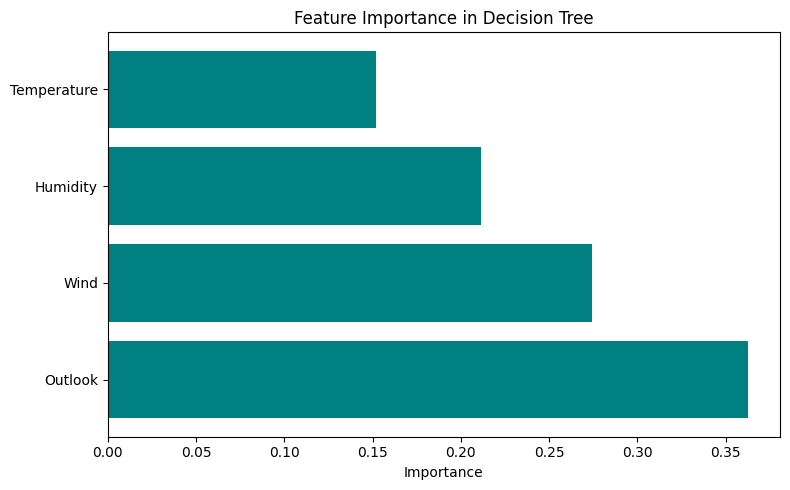

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': ['Outlook', 'Temperature', 'Humidity', 'Wind'],
    'Importance': dt_classifier.feature_importances_
}).sort_values('Importance', ascending=False)
+_
print("Feature Importance:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal')
plt.xlabel('Importance')
plt.title('Feature Importance in Decision Tree')
plt.tight_layout()
plt.show()

## 11. Make Predictions on New Data

In [23]:
# Predict on training data (since dataset is small)
y_pred = dt_classifier.predict(X)

print("Training Accuracy:", accuracy_score(y, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred))
print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=['No', 'Yes']))

Training Accuracy: 1.0

Confusion Matrix:
[[5 0]
 [0 9]]

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         5
         Yes       1.00      1.00      1.00         9

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



In [ ]:
# Predict for new unseen scenarios
print("Predicting for new weather conditions:")
print("=" * 50)

new_data = {
    'Scenario 1': {'Outlook': 'Sunny', 'Temperature': 'Cool', 'Humidity': 'High', 'Wind': 'Strong'},
    'Scenario 2': {'Outlook': 'Overcast', 'Temperature': 'Mild', 'Humidity': 'Normal', 'Wind': 'Weak'},
    'Scenario 3': {'Outlook': 'Rain', 'Temperature': 'Mild', 'Humidity': 'Normal', 'Wind': 'weak'},
}

for name, conditions in new_data.items():
    encoded = [label_encoders[col].transform([conditions[col]])[0] for col in ['Outlook', 'Temperature', 'Humidity', 'Wind']]
    prediction = dt_classifier.predict([encoded])[0]
    result = label_encoders['PlayTennis'].inverse_transform([prediction])[0]
    print(f"\n{name}: {conditions}")
    print(f"  => Play Tennis? {result}")

Predicting for new weather conditions:

Scenario 1: {'Outlook': 'Sunny', 'Temperature': 'Cool', 'Humidity': 'High', 'Wind': 'Strong'}
  => Play Tennis? No

Scenario 2: {'Outlook': 'Overcast', 'Temperature': 'Mild', 'Humidity': 'Normal', 'Wind': 'Weak'}
  => Play Tennis? Yes


ValueError: y contains previously unseen labels: 'weak'

## 12. Controlling Tree Complexity

Decision Trees can easily **overfit** by growing too deep. We can control this with parameters like `max_depth`.

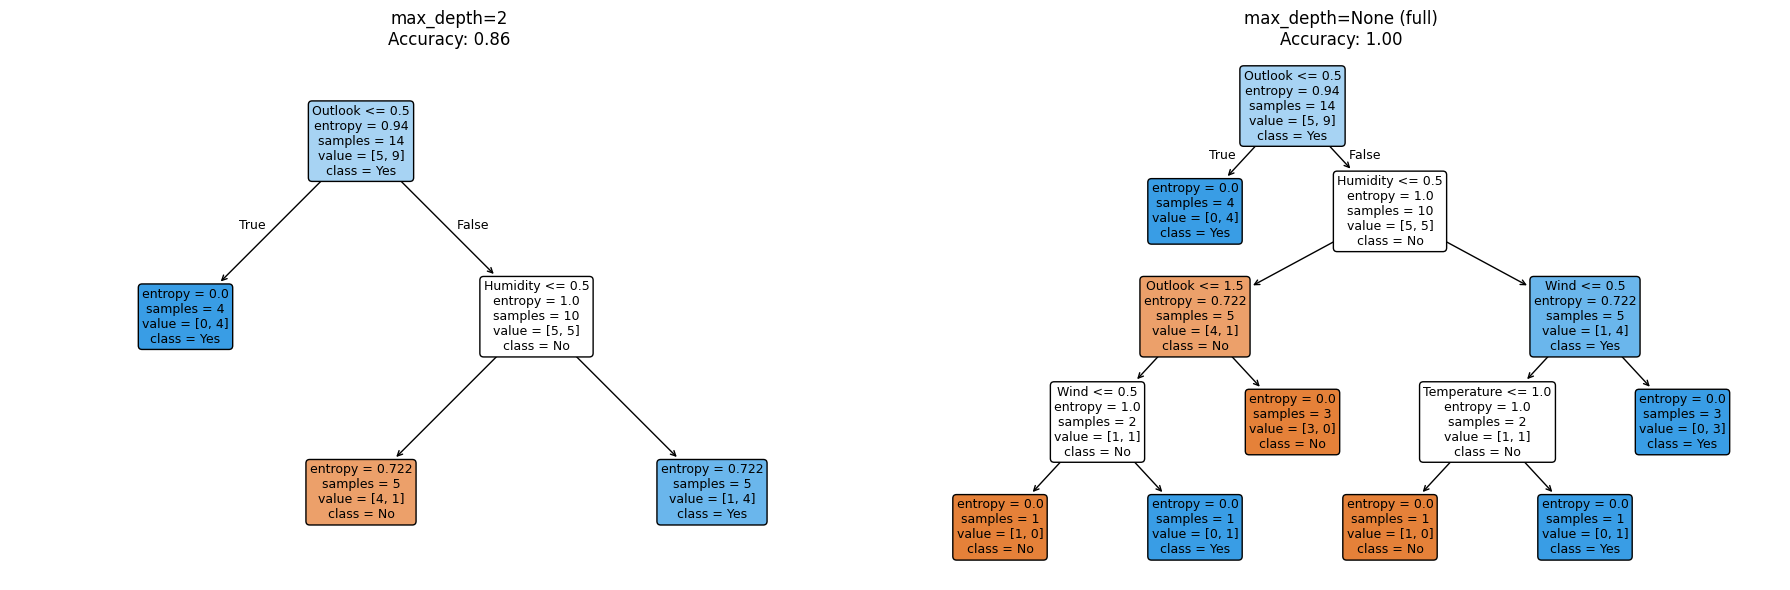

In [14]:
# Compare trees with different max_depth
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for i, depth in enumerate([2, None]):
    dt = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    dt.fit(X, y)
    acc = accuracy_score(y, dt.predict(X))
    
    plot_tree(dt,
              feature_names=['Outlook', 'Temperature', 'Humidity', 'Wind'],
              class_names=['No', 'Yes'],
              filled=True, rounded=True, fontsize=9,
              ax=axes[i])
    title = f"max_depth={depth if depth else 'None (full)'}\nAccuracy: {acc:.2f}"
    axes[i].set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

## 13. Decision Tree vs KNN vs Logistic Regression

| Aspect | Decision Tree | KNN | Logistic Regression |
|--------|--------------|-----|--------------------|
| How it learns | Builds rules by splitting | Memorizes data | Learns weights |
| Handles categorical | Yes (with encoding) | No (needs numbers) | No (needs numbers) |
| Feature scaling | Not required | Required | Recommended |
| Interpretability | Very high (visual tree) | Low | Medium (coefficients) |
| Overfitting risk | High (deep trees) | Medium (small K) | Low |
| Decision boundary | Axis-aligned (rectangular) | Flexible, curved | Linear |
| Best for | Rule-based, explainable models | Small data, complex patterns | Large data, linear patterns |

## Summary

- **Decision Trees** split data by asking yes/no questions about features
- **Entropy** measures disorder; **Information Gain** picks the best feature to split on
- The tree grows until all leaves are pure (or a stopping condition is met)
- Trees are highly **interpretable** — you can read the rules directly
- Watch out for **overfitting** — use `max_depth` or pruning to control complexity
- No feature scaling needed (unlike KNN and Logistic Regression)